# Casey coarse-class confidence sweep at k17

Compare Mean, Pointwise-MLP, and GT with mixed-cell batches across five cell-level folds. Every run uses the new TEASAR k17 windows. Casey coarse-label confidence cutoffs are 0, 0.3, 0.5, 0.7, and 0.9. Neurons are matched to Casey by root ID or stable cell identity; ChC and L6b are excluded. The L2 targets are pyramidal, thalamocortical, BasketFam, MartFam, BipFam, and NglFam.

All 30 extended-axon thalamocortical cells use the source-manifest label because Casey provides no coarse confidence score for them. Each held-out fold contains six thalamocortical cells. Folds are balanced by Casey fine type within each confidence cohort; a cell keeps the same held-out fold across cutoffs. The test population changes with the confidence cutoff.


In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "results" / "presynaptic").is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from analysis.presynaptic.casey_confidence_native.casey_confidence_comparison import (
    COHORT_ROOT, RESULT_ROOT, coarse_split_matrix, load_coarse_cohort_counts, load_summaries, load_training_curves,
    plot_confusions, plot_metric_comparison, plot_training_curves,
)
RESULT_ROOT

PosixPath('/orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/results/presynaptic/casey_coarse_confidence_with_tc_mixed16_stratified5/scale16/k17')

## Cohort sizes by Casey coarse type

Train and test cell counts by Casey coarse type in the selected held-out fold after each confidence cutoff. Counts are planned from cell metadata until the k17 windows finish building, then read from the finalized fold manifests. Thalamocortical appears as a separate source-manifest type.


In [2]:
from analysis.presynaptic.casey_confidence_native import casey_confidence_comparison as confidence_analysis
FOLD = globals().get("FOLD", 0)  # Held-out fold; change to 0–4.
cohorts = confidence_analysis.load_coarse_cohort_counts(fold=FOLD)
if cohorts.empty:
    print(f"No cohort files found under {confidence_analysis.COHORT_ROOT}")
else:
    if cohorts.attrs.get("planned"):
        print("Planned cell splits from Casey labels; TEASAR window builds are still running.")
    display(cohorts.sort_values(["confidence", "coarse_type"]).reset_index(drop=True))


,confidence,coarse_type,train_cells,test_cells
0,0.0,BasketFam,136,35
1,0.0,BipFam,91,22
2,0.0,L2,175,44
3,0.0,L3,198,49
4,0.0,L4,428,107
...,...,...,...,...
60,0.9,L6CT,142,35
61,0.9,L6IT,73,20
62,0.9,MartFam,80,20
63,0.9,NglFam,15,3


## Cell splits by Casey coarse type

Rows are Casey coarse types for the selected held-out fold. Each confidence level has **Train** and **Test** columns containing cell counts. Thalamocortical has no Casey coarse label, so its source-manifest type appears as a separate row. The five folds are balanced by Casey fine type within each confidence cohort.


In [3]:
from analysis.presynaptic.casey_confidence_native import casey_confidence_comparison as confidence_analysis
FOLD = globals().get("FOLD", 0)  # Held-out fold; change to 0–4.
coarse_cohorts = confidence_analysis.load_coarse_cohort_counts(fold=FOLD)
if coarse_cohorts.empty:
    print(f"No cohort files found under {confidence_analysis.COHORT_ROOT}")
else:
    if coarse_cohorts.attrs.get("planned"):
        print("Planned cell splits from Casey labels; TEASAR window builds are still running.")
    matrix = confidence_analysis.coarse_split_matrix(coarse_cohorts)
    display(
        matrix.style
        .set_caption(f"Cell counts by Casey coarse type and minimum confidence — fold {FOLD}")
        .format("{:d}")
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#edf2f7"), ("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
        ])
    )


## Training progress

Curves appear as soon as a mixed-cell run writes its first epoch. Every retained window is used once per epoch.

,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,cell_precision_BasketFam,cell_precision_BipFam,cell_precision_MartFam,cell_precision_NglFam,cell_precision_pyramidal,cell_precision_thalamocortical,confidence,fold,run,model
59,29,0.273631,0.854588,0.609205,0.715606,0.626809,0.923645,0.668333,0.772457,0.682614,...,0.972222,0.000000,0.730769,1.0,0.931751,1.0,0.0,0,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,Mean
89,29,0.265602,0.860523,0.616879,0.745954,0.636310,0.926108,0.675909,0.856717,0.696998,...,0.972222,0.500000,0.730769,1.0,0.937313,1.0,0.0,0,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,Pointwise-MLP
29,29,0.271507,0.848001,0.591172,0.738489,0.602438,0.918719,0.620000,0.598921,0.609165,...,0.972222,0.000000,0.692308,0.0,0.928994,1.0,0.0,0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_mixe...,GT
149,29,0.274435,0.836328,0.641123,0.670621,0.648752,0.931818,0.693849,0.882399,0.712569,...,1.000000,0.666667,0.677419,1.0,0.950311,1.0,0.3,0,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,Mean
179,29,0.269077,0.848285,0.653627,0.687615,0.665771,0.931818,0.693849,0.882399,0.712569,...,1.000000,0.666667,0.677419,1.0,0.950311,1.0,0.3,0,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,Pointwise-MLP
119,29,0.275773,0.846222,0.631695,0.672093,0.646591,0.929293,0.693305,0.877472,0.709952,...,0.970588,0.666667,0.677419,1.0,0.950156,1.0,0.3,0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_mixe...,GT
239,29,0.264969,0.775217,0.594079,0.715688,0.605946,0.937500,0.701307,0.898156,0.753693,...,0.969697,0.521739,0.933333,1.0,0.964169,1.0,0.5,0,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,Mean
269,29,0.257886,0.792568,0.599543,0.727073,0.613563,0.945312,0.722141,0.913052,0.775933,...,0.969697,0.600000,0.944444,1.0,0.964169,1.0,0.5,0,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,Pointwise-MLP
209,29,0.263729,0.784102,0.570026,0.775928,0.574285,0.908854,0.583252,0.701175,0.616673,...,0.969697,0.291667,1.000000,0.0,0.945687,1.0,0.5,0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_mixe...,GT
329,29,0.258648,0.858582,0.663153,0.724001,0.679787,0.935933,0.710507,0.953193,0.731937,...,1.000000,1.000000,0.777778,1.0,0.941379,1.0,0.7,0,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,Mean


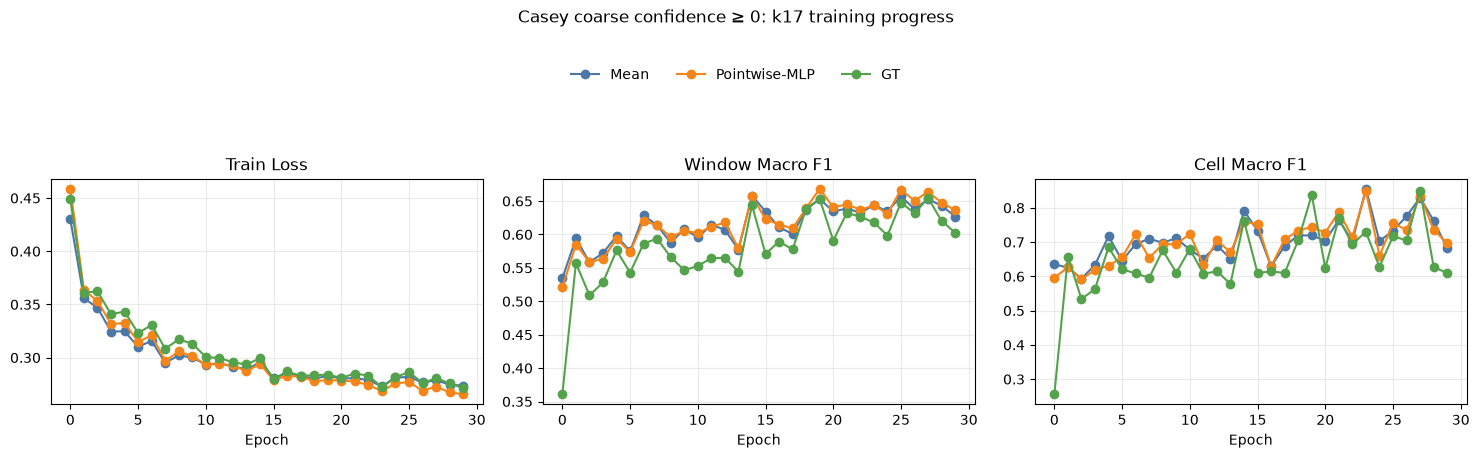

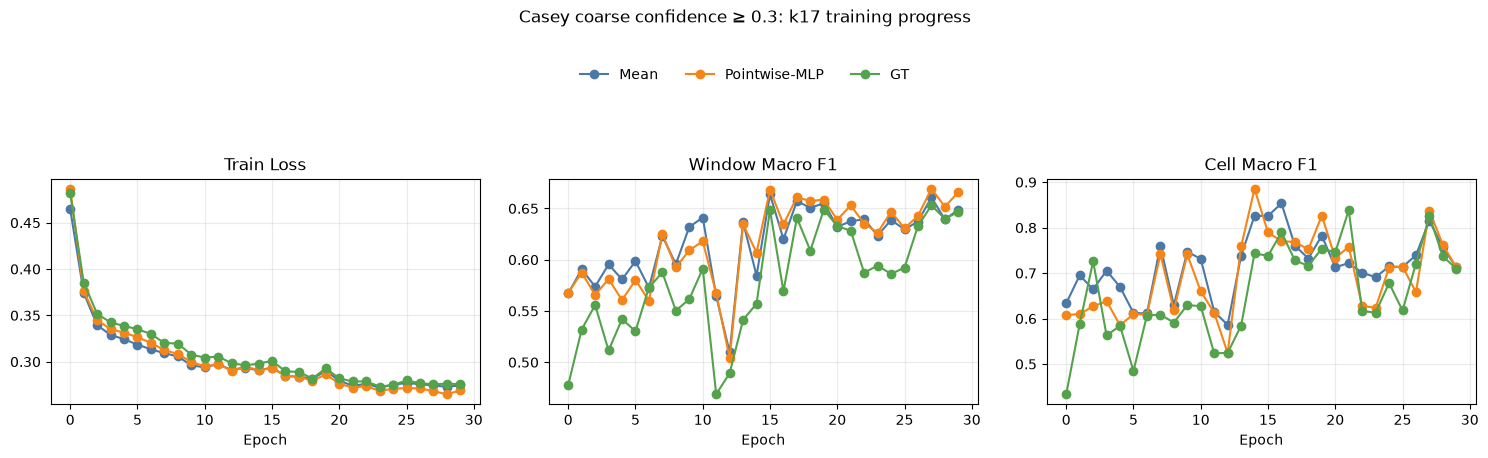

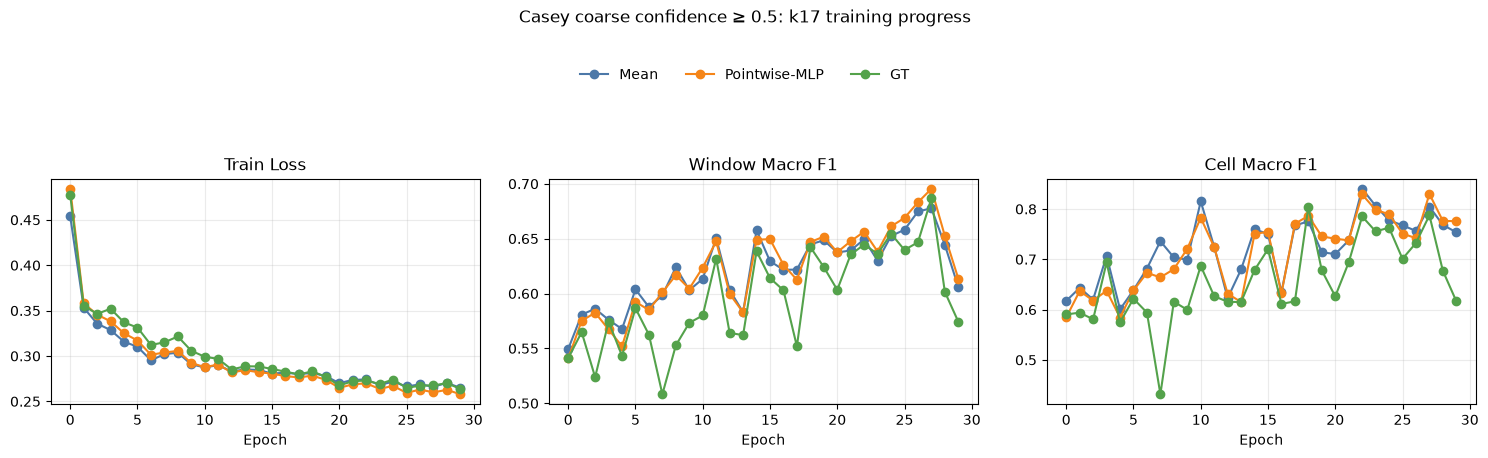

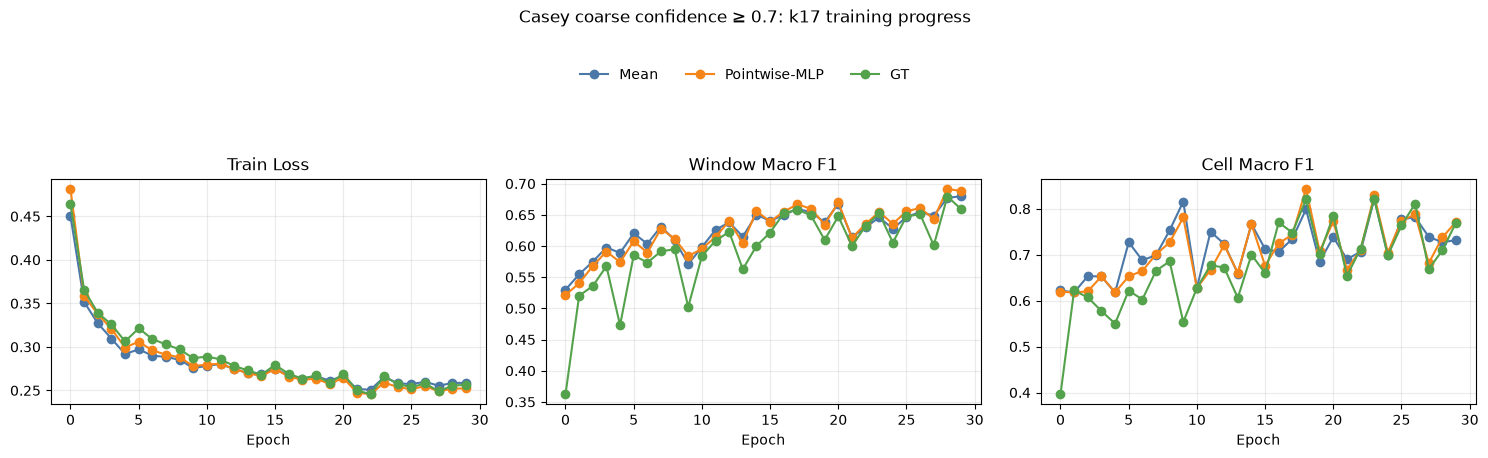

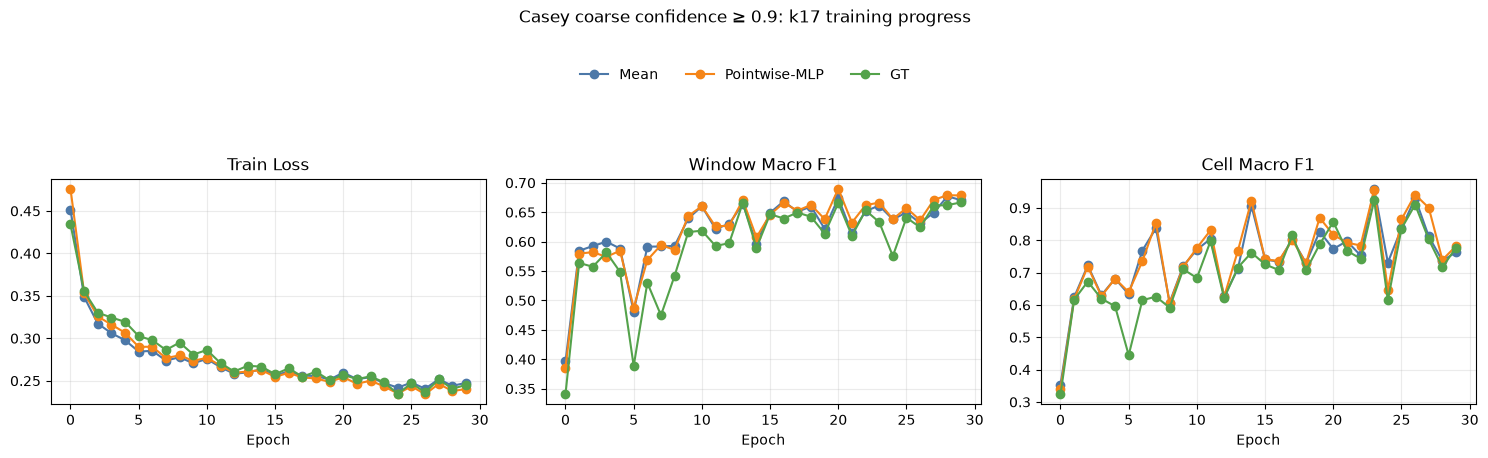

In [4]:
curves = load_training_curves()
if curves.empty:
    print("No completed epochs yet.")
else:
    display(curves.groupby(["confidence", "model", "run"], observed=True).tail(1)
            .sort_values(["confidence", "model"]))
    for fig in plot_training_curves(curves):
        display(fig)
        plt.close(fig)

## Best-checkpoint test metrics

Each point uses the checkpoint selected by the highest **window macro F1**. The selected epoch is labeled on the first panel. Cell macro F1 is evaluated at that same checkpoint, so it need not equal the maximum cell macro F1 visible in the training curves. Error bars show the standard deviation across completed folds.


,confidence,fold,model,run,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1
0,0.0,0,Mean,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,14,0.843407,0.675100,0.656081,0.658074,0.933498,0.766818,0.895113,0.791284
1,0.0,0,Pointwise-MLP,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,19,0.845993,0.670765,0.666554,0.668352,0.933498,0.713722,0.893325,0.744498
2,0.0,0,GT,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_mixe...,27,0.793047,0.673539,0.674448,0.654595,0.953202,0.840322,0.891951,0.850434
3,0.3,0,Mean,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,15,0.831132,0.679603,0.664846,0.663716,0.944444,0.799802,0.878623,0.825746
4,0.3,0,Pointwise-MLP,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,27,0.848418,0.675759,0.681577,0.669173,0.944444,0.830357,0.941050,0.837204
5,0.3,0,GT,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_mixe...,27,0.843748,0.659382,0.673843,0.652965,0.941919,0.822421,0.940569,0.825281
6,0.5,0,Mean,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,27,0.852491,0.692140,0.668322,0.677696,0.940104,0.783333,0.887376,0.804599
7,0.5,0,Pointwise-MLP,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,27,0.858578,0.708473,0.686882,0.695407,0.945312,0.806381,0.898970,0.829939
8,0.5,0,GT,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_mixe...,27,0.858294,0.689938,0.686505,0.686735,0.932292,0.773874,0.869728,0.787475
9,0.7,0,Mean,gnn_lcpn_scratch_mean_resnet4x128_n17_mixed16_...,29,0.858582,0.663153,0.724001,0.679787,0.935933,0.710507,0.953193,0.731937


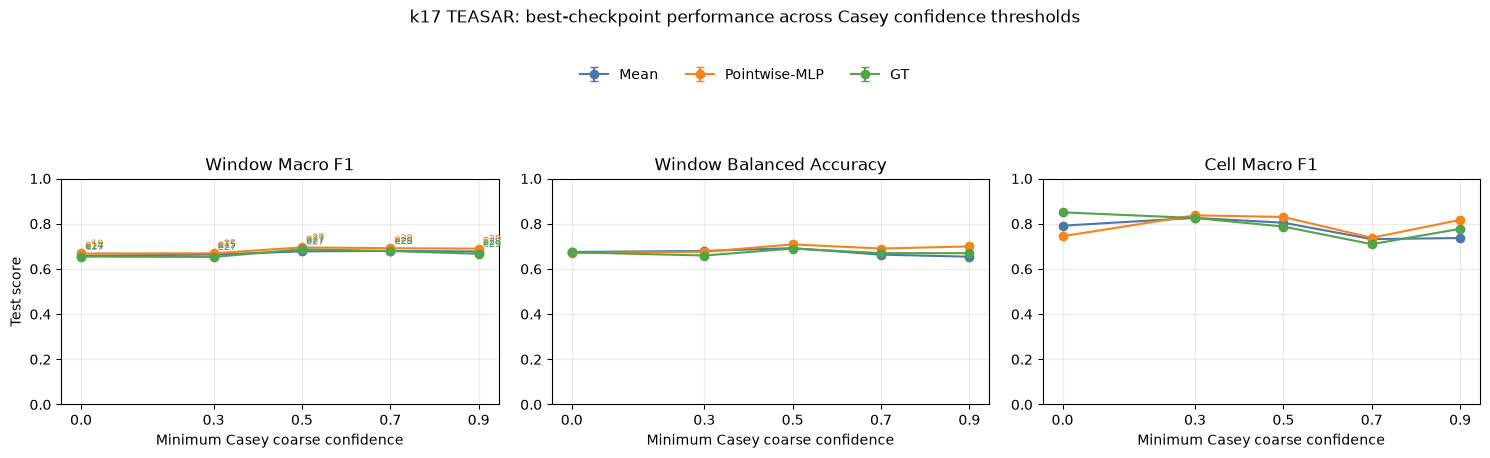

In [5]:
summary, payloads = load_summaries()
if summary.empty:
    print("Final summaries appear after training finishes.")
else:
    display(summary)
    fig = plot_metric_comparison(summary)
    display(fig)
    plt.close(fig)

## Confusion matrices

Rows are true classes, columns are predictions. Each row is normalized to sum to one.

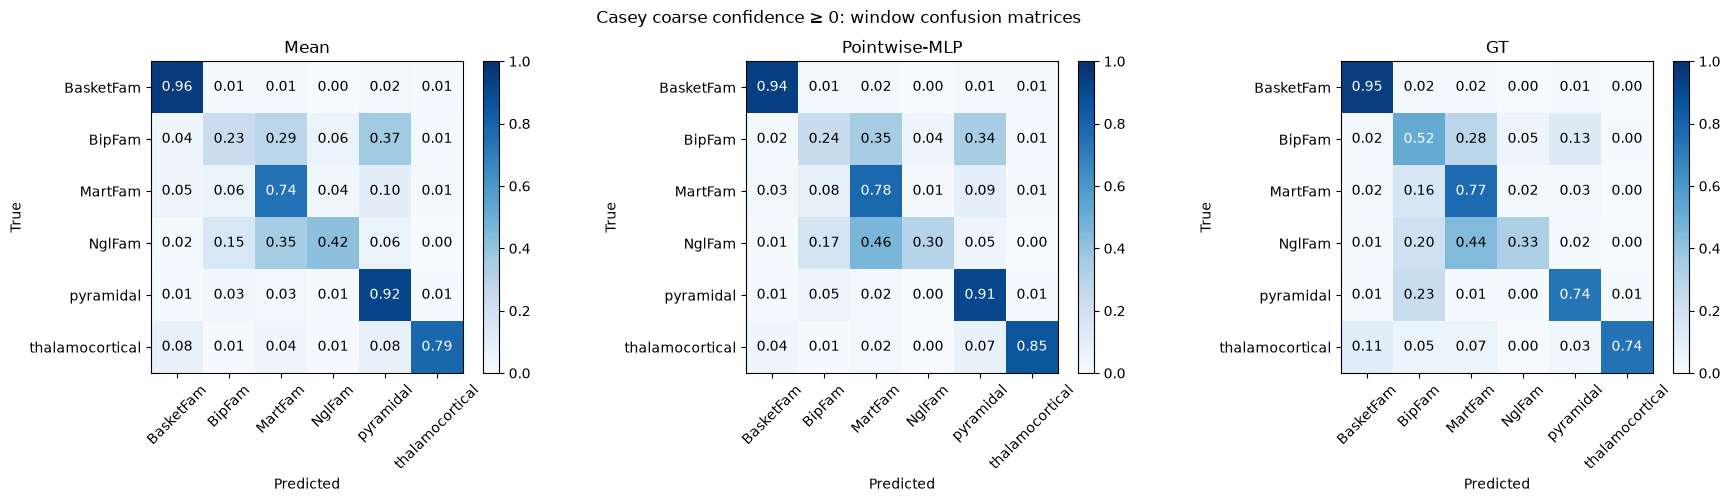

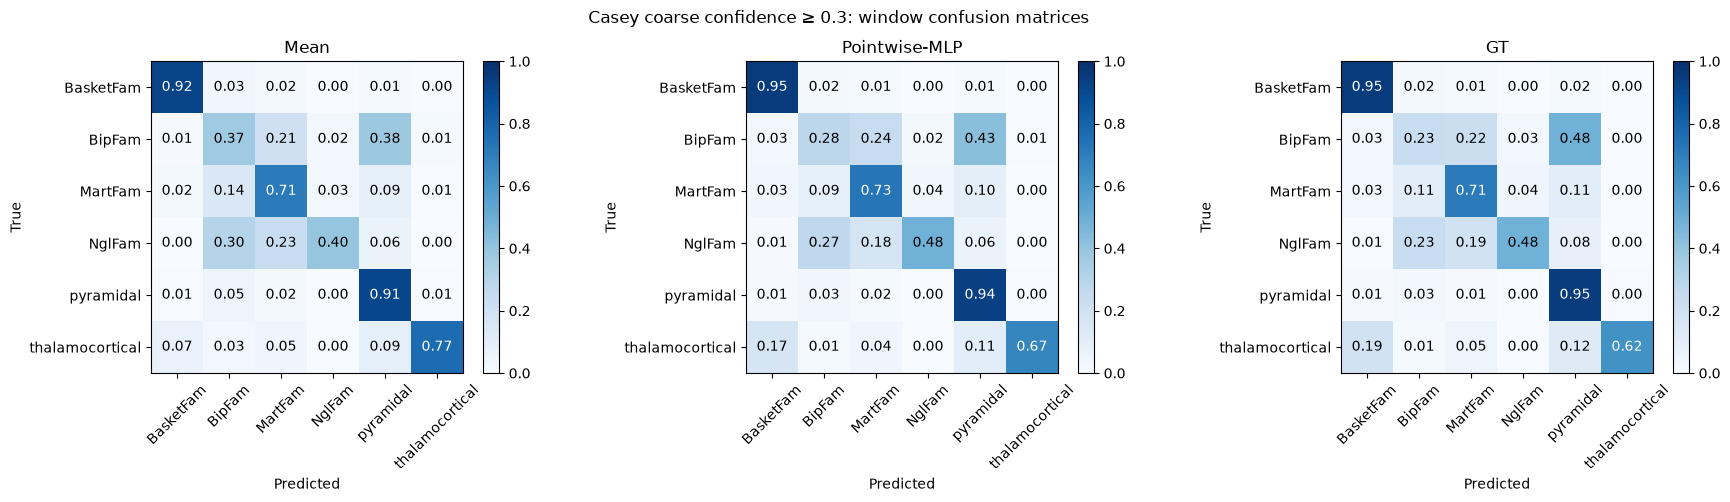

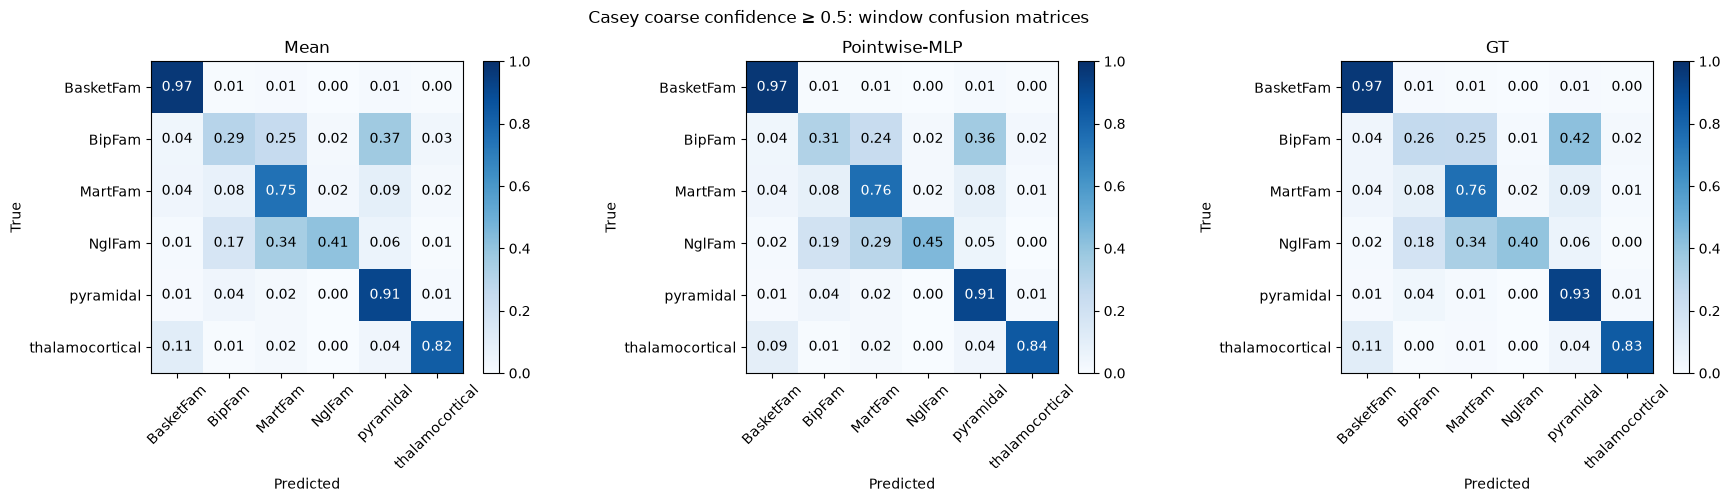

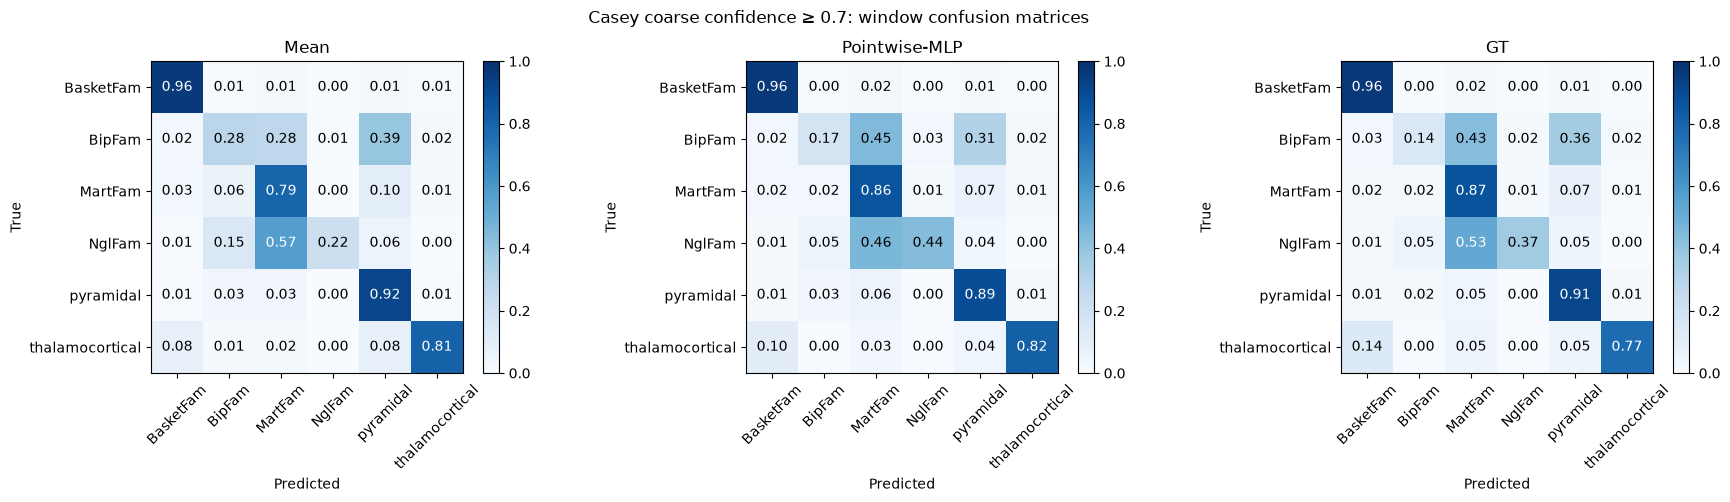

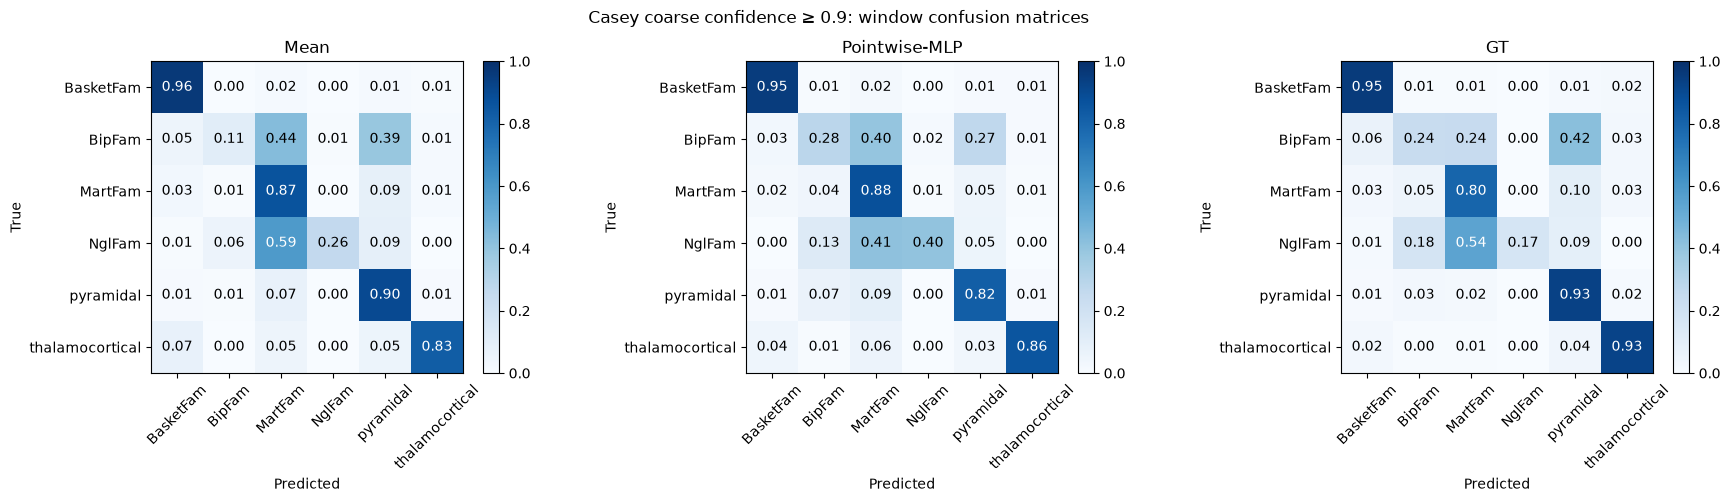

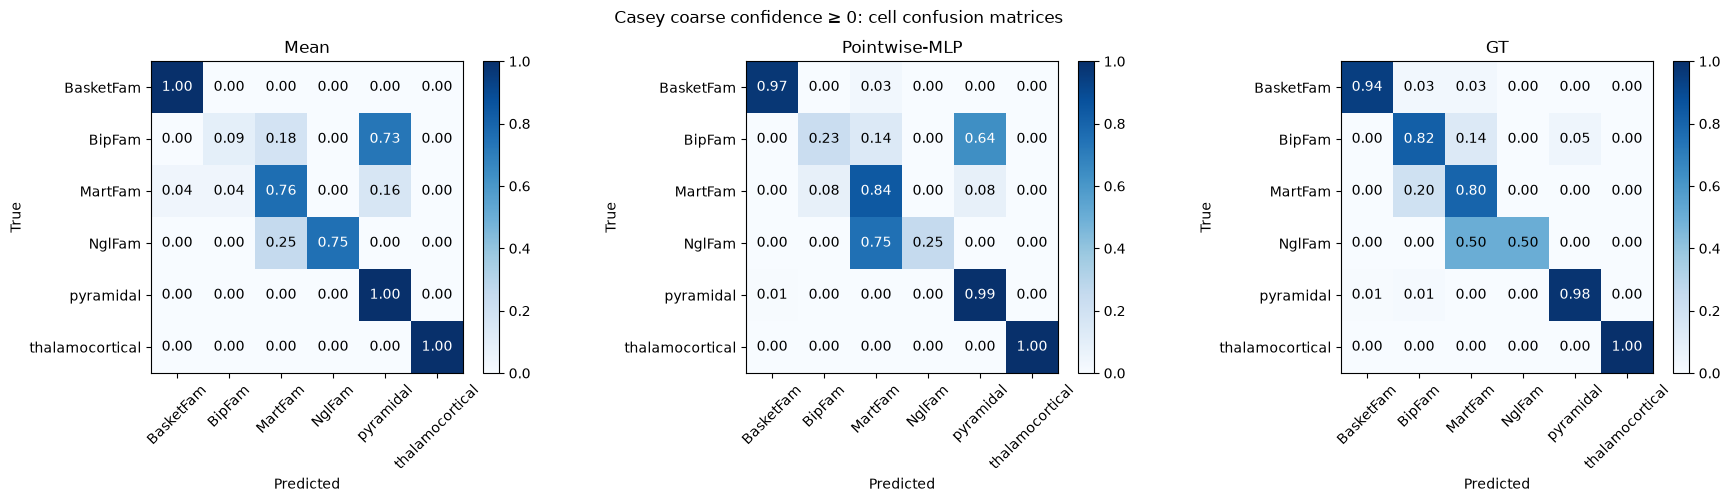

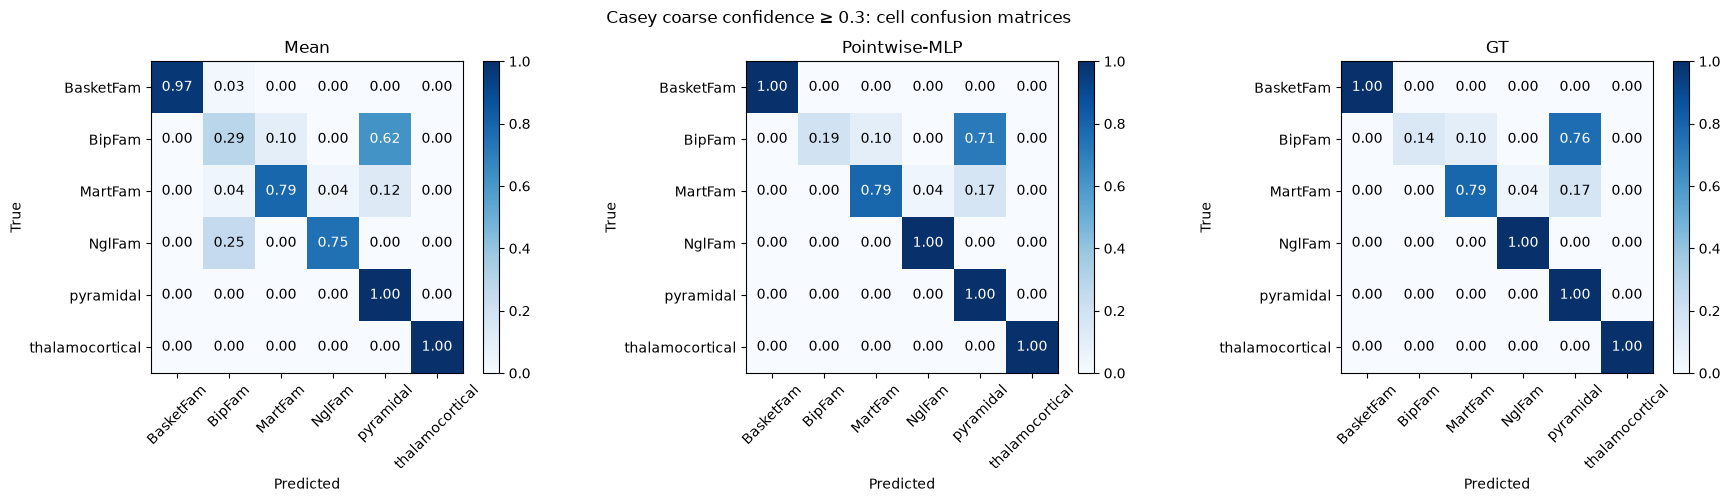

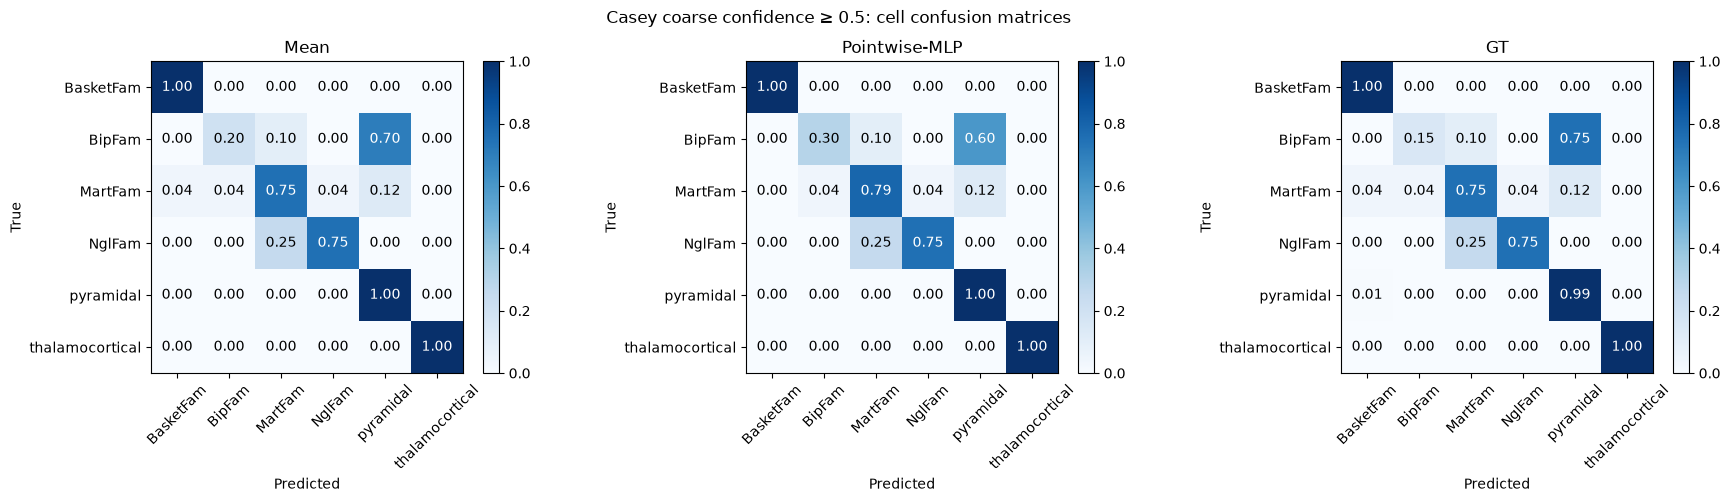

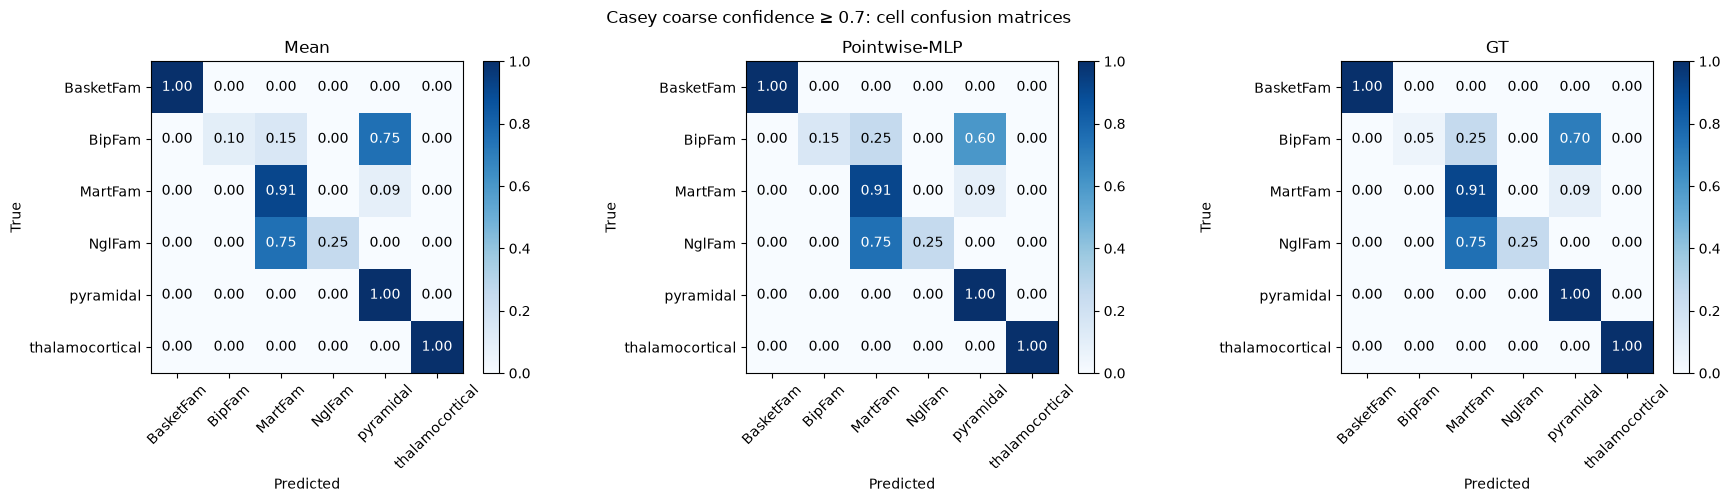

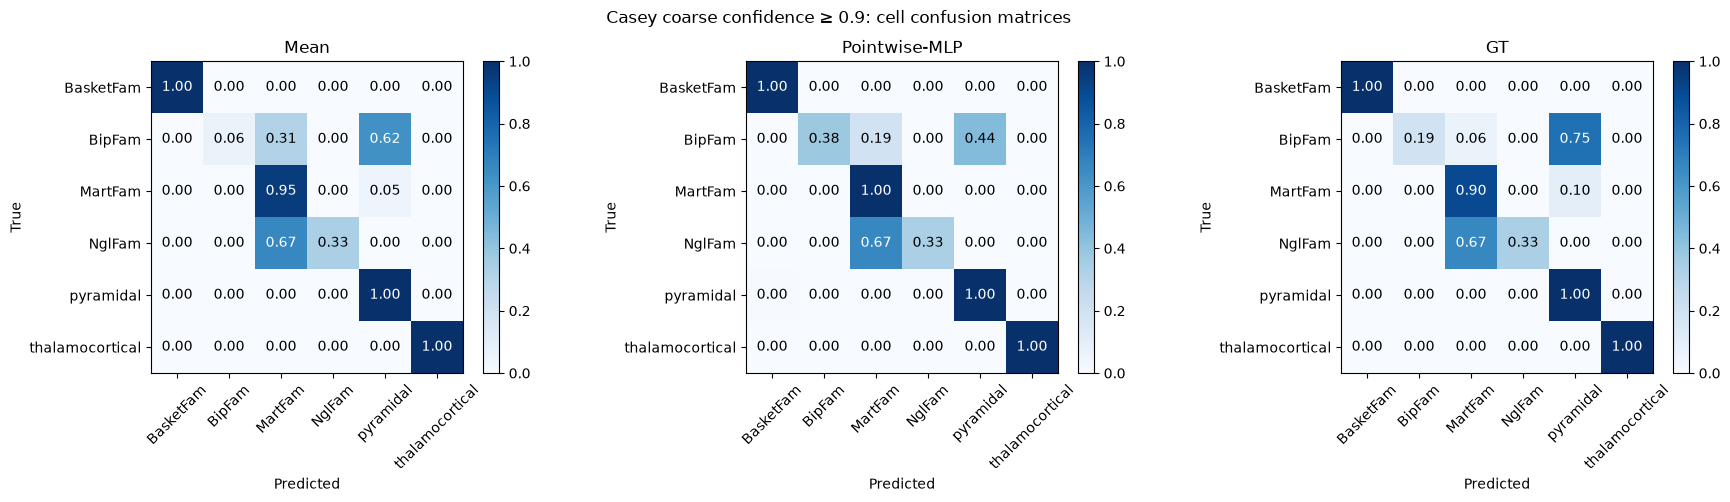

In [6]:
for scope in ("window", "cell"):
    for fig in plot_confusions(payloads, scope=scope, normalize=True):
        display(fig)
        plt.close(fig)